# Chunk-Level Model Performance

- trains:
  - a naive mean-time mode* by WorkCode
  - a linear regression with log response
  - XGBoost with distance-related features
  - XGBoost without distance-related features
- builds fixed-length task chunks on the test set and compares aggregated block-level performance

In [9]:
from pathlib import Path
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.linear_model import LinearRegression
from xgboost import XGBRegressor
from sklearn.ensemble import RandomForestRegressor

import importlib
import feature_engineer
importlib.reload(feature_engineer)

from feature_engineer import get_engineered_df

pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 200)

PATH = Path("../data/processed")
WAREHOUSE = "OE"

WORKCODES = ['10', '20', '30']
#WORKCODES = ["1", "2", "3", "4", "5", "6"]

MAX_TIME = 300
BLOCK_SIZE = 20
RANDOM_STATE = 2026

In [10]:
def resolve_data_path(warehouse):
    fname = f"{warehouse.lower()}_detailed.parquet"
    return PATH / fname

def load_engineered_data(warehouse, workcode, max_time=300):
    """
    Load clean engineered data using feature_engineer.py
    """
    data_path = resolve_data_path(warehouse)

    # get_engineered_df is expected to return:
    # df, features, cat_cols
    d, features_all, cat_cols_all = get_engineered_df(
        file_path=data_path,
        warehouse=warehouse,
        max_time=max_time,
        work_code=workcode, 
        sequenced=True,
    )

    d = d.copy()
    d["Timestamp"] = pd.to_datetime(d["Timestamp"], errors="coerce")
    d = d.dropna(subset=["Timestamp"]).copy()
    d["date"] = d["Timestamp"].dt.date
    d["WorkCode"] = d["WorkCode"].astype(str).str.replace(".0", "", regex=False)

    # distance-related features to exclude in no-distance model
    distance_num = ["Travel_Distance"]
    distance_cat = ["same_aisle", "same_location", "same_level"]

    features_with_distance = features_all.copy()
    cat_cols_with_distance = cat_cols_all.copy()

    features_without_distance = [
        f for f in features_all
        if f not in distance_num + distance_cat
    ]
    cat_cols_without_distance = [
        c for c in cat_cols_all
        if c not in distance_cat
    ]

    return (
        d,
        features_with_distance,
        features_without_distance,
        cat_cols_with_distance,
        cat_cols_without_distance,
    )

def split_by_days(df, test_ratio=0.15):
    """
    Chronological split where the test set is the last ~10–20% of days.
    """

    all_days = sorted(df["date"].dropna().unique())
    n_days = len(all_days)

    # number of test days
    n_test_days = max(1, int(round(n_days * test_ratio)))
    test_days = all_days[-n_test_days:]

    train_df = df[df["date"] < test_days[0]].copy()
    test_df = df[df["date"].isin(test_days)].copy()

    return train_df, test_df, test_days


def make_X(train_df, test_df, features, cat_cols):
    X_train = pd.get_dummies(train_df[features], columns=cat_cols, drop_first=True)
    X_test = pd.get_dummies(test_df[features], columns=cat_cols, drop_first=True)
    X_test = X_test.reindex(columns=X_train.columns, fill_value=0)

    X_train = X_train.replace([np.inf, -np.inf], np.nan).fillna(0).astype(float)
    X_test = X_test.replace([np.inf, -np.inf], np.nan).fillna(0).astype(float)
    return X_train, X_test

def eval_predictions(y_true, pred):
    return {
        "r2": r2_score(y_true, pred),
        "mae": mean_absolute_error(y_true, pred),
        "rmse": np.sqrt(mean_squared_error(y_true, pred)),
    }

def make_test_blocks(test_df, block_size=10):
    d = test_df.sort_values(["UserID", "Timestamp"]).copy()
    blocks = []
    block_rows = []

    for (uid, day), g in d.groupby(["UserID", "date"], sort=False):
        g = g.sort_values("Timestamp").reset_index().rename(columns={"index": "orig_index"}).copy()
        n = len(g)

        for start in range(0, n, block_size):
            chunk = g.iloc[start:start + block_size].copy()
            if len(chunk) < block_size:
                continue
            if chunk["WorkCode"].nunique() != 1:
                continue
            if (chunk["Time_Delta_sec"] > MAX_TIME).any():
                continue

            block_id = f"{uid}_{day}_{start // block_size}"
            chunk["BlockID"] = block_id
            block_rows.append(chunk)

            blocks.append({
                "BlockID": block_id,
                "UserID": uid,
                "date": day,
                "WorkCode": chunk["WorkCode"].iloc[0],
                "n_tasks": len(chunk),
                "actual_time": chunk["Time_Delta_sec"].sum(),
                "start_ts": chunk["Timestamp"].min(),
                "end_ts": chunk["Timestamp"].max(),
            })

    block_df = pd.DataFrame(blocks)
    block_rows_df = pd.concat(block_rows, ignore_index=True) if block_rows else pd.DataFrame()
    return block_df, block_rows_df

In [11]:
data_path = resolve_data_path(WAREHOUSE)
raw_df = pd.read_parquet(data_path)

all_task_results = []
all_block_results = []
all_block_detail = []

for wc in WORKCODES:
    df_wc, features_wd, features_nod, cat_cols_wd, cat_cols_nod = load_engineered_data(
        warehouse=WAREHOUSE,
        workcode=wc,
        max_time=MAX_TIME
    )

    train_df, test_df, test_days = split_by_days(df_wc)

    print(f"WC {wc} | train={len(train_df)} | test={len(test_df)}")

    y_train = train_df["Time_Delta_sec"].astype(float)
    y_test = test_df["Time_Delta_sec"].astype(float)

    # ----------------------------
    # Naive mean
    # ----------------------------
    t0 = time.perf_counter()
    naive_mean = y_train.mean()
    pred_naive = np.repeat(naive_mean, len(y_test))
    naive_runtime = time.perf_counter() - t0
    m_naive = eval_predictions(y_test, pred_naive)

    all_task_results.append({
        "Warehouse": WAREHOUSE,
        "WorkCode": wc,
        "Model": "Naive mean",
        "n_train_rows": len(train_df),
        "n_test_rows": len(test_df),
        "runtime_sec": naive_runtime,
        **m_naive
    })

    # naive median
    t0 = time.perf_counter()
    naive_median = y_train.median()
    pred_naive_median = np.repeat(naive_median, len(y_test))
    naive_median_runtime = time.perf_counter() - t0
    m_naive_median = eval_predictions(y_test, pred_naive_median)

    all_task_results.append({
        "Warehouse": WAREHOUSE,
        "WorkCode": wc,
        "Model": "Naive median",
        "n_train_rows": len(train_df),
        "n_test_rows": len(test_df),
        "runtime_sec": naive_median_runtime,
        **m_naive_median
    })

    # ----------------------------
    # Linear regression with distance
    # ----------------------------
    X_train_lr, X_test_lr = make_X(train_df, test_df, features_wd, cat_cols_wd)

    t0 = time.perf_counter()
    lr_wd = LinearRegression()
    lr_wd.fit(X_train_lr, np.log(y_train))
    pred_lr = np.exp(lr_wd.predict(X_test_lr))
    lr_runtime = time.perf_counter() - t0
    m_lr = eval_predictions(y_test, pred_lr)

    all_task_results.append({
        "Warehouse": WAREHOUSE,
        "WorkCode": wc,
        "Model": "Linear regression (with distance)",
        "n_train_rows": len(train_df),
        "n_test_rows": len(test_df),
        "runtime_sec": lr_runtime,
        **m_lr
    })

    # ----------------------------
    # Linear regression without distance
    # ----------------------------
    X_train_lr_n, X_test_lr_n = make_X(train_df, test_df, features_nod, cat_cols_nod)

    t0 = time.perf_counter()
    lr_nod = LinearRegression()
    lr_nod.fit(X_train_lr_n, np.log(y_train))
    pred_lr_n = np.exp(lr_nod.predict(X_test_lr_n))
    lr_n_runtime = time.perf_counter() - t0
    m_lr_n = eval_predictions(y_test, pred_lr_n)

    all_task_results.append({
        "Warehouse": WAREHOUSE,
        "WorkCode": wc,
        "Model": "Linear regression (without distance)",
        "n_train_rows": len(train_df),
        "n_test_rows": len(test_df),
        "runtime_sec": lr_n_runtime,
        **m_lr_n
    })

    # ----------------------------
    # Random Forest with distance
    # ----------------------------
    X_train_rf_d, X_test_rf_d = make_X(train_df, test_df, features_wd, cat_cols_wd)

    t0 = time.perf_counter()
    rf_d = RandomForestRegressor(
        n_estimators=400,
        max_depth=None,
        min_samples_leaf=2,
        random_state=RANDOM_STATE,
        n_jobs=-1,
    )
    rf_d.fit(X_train_rf_d, y_train)
    pred_rf_d = rf_d.predict(X_test_rf_d)
    rf_d_runtime = time.perf_counter() - t0
    m_rf_d = eval_predictions(y_test, pred_rf_d)

    all_task_results.append({
        "Warehouse": WAREHOUSE,
        "WorkCode": wc,
        "Model": "Random Forest (with distance)",
        "n_train_rows": len(train_df),
        "n_test_rows": len(test_df),
        "runtime_sec": rf_d_runtime,
        **m_rf_d
    })

    # ----------------------------
    # Random Forest without distance
    # ----------------------------
    X_train_rf_n, X_test_rf_n = make_X(train_df, test_df, features_nod, cat_cols_nod)

    t0 = time.perf_counter()
    rf_n = RandomForestRegressor(
        n_estimators=400,
        max_depth=None,
        min_samples_leaf=2,
        random_state=RANDOM_STATE,
        n_jobs=-1,
    )
    rf_n.fit(X_train_rf_n, y_train)
    pred_rf_n = rf_n.predict(X_test_rf_n)
    rf_n_runtime = time.perf_counter() - t0
    m_rf_n = eval_predictions(y_test, pred_rf_n)

    all_task_results.append({
        "Warehouse": WAREHOUSE,
        "WorkCode": wc,
        "Model": "Random Forest (without distance)",
        "n_train_rows": len(train_df),
        "n_test_rows": len(test_df),
        "runtime_sec": rf_n_runtime,
        **m_rf_n
    })

    # ----------------------------
    # XGBoost with distance
    # ----------------------------
    X_train_xgb_d, X_test_xgb_d = make_X(train_df, test_df, features_wd, cat_cols_wd)

    t0 = time.perf_counter()
    xgb_d = XGBRegressor(
        n_estimators=1200,
        learning_rate=0.03,
        max_depth=6,
        min_child_weight=3,
        subsample=0.8,
        colsample_bytree=0.8,
        reg_alpha=0.0,
        reg_lambda=1.0,
        objective="reg:tweedie",
        tweedie_variance_power=1.3,
        tree_method="hist",
        random_state=RANDOM_STATE,
        n_jobs=-1,
    )
    xgb_d.fit(X_train_xgb_d, y_train)
    pred_xgb_d = xgb_d.predict(X_test_xgb_d)
    xgb_d_runtime = time.perf_counter() - t0
    m_xgb_d = eval_predictions(y_test, pred_xgb_d)

    all_task_results.append({
        "Warehouse": WAREHOUSE,
        "WorkCode": wc,
        "Model": "XGBoost (with distance)",
        "n_train_rows": len(train_df),
        "n_test_rows": len(test_df),
        "runtime_sec": xgb_d_runtime,
        **m_xgb_d
    })

    # ----------------------------
    # XGBoost without distance
    # ----------------------------
    X_train_xgb_n, X_test_xgb_n = make_X(train_df, test_df, features_nod, cat_cols_nod)

    t0 = time.perf_counter()
    xgb_n = XGBRegressor(
        n_estimators=1200,
        learning_rate=0.03,
        max_depth=6,
        min_child_weight=3,
        subsample=0.8,
        colsample_bytree=0.8,
        reg_alpha=0.0,
        reg_lambda=1.0,
        objective="reg:tweedie",
        tweedie_variance_power=1.3,
        tree_method="hist",
        random_state=RANDOM_STATE,
        n_jobs=-1,
    )
    xgb_n.fit(X_train_xgb_n, y_train)
    pred_xgb_n = xgb_n.predict(X_test_xgb_n)
    xgb_n_runtime = time.perf_counter() - t0
    m_xgb_n = eval_predictions(y_test, pred_xgb_n)

    all_task_results.append({
        "Warehouse": WAREHOUSE,
        "WorkCode": wc,
        "Model": "XGBoost (without distance)",
        "n_train_rows": len(train_df),
        "n_test_rows": len(test_df),
        "runtime_sec": xgb_n_runtime,
        **m_xgb_n
    })

    # ----------------------------
    # Block-level evaluation
    # ----------------------------
    block_df, block_rows_df = make_test_blocks(test_df, block_size=BLOCK_SIZE)

    if len(block_df) == 0:
        print(f"No valid blocks for WC {wc}")
        continue

    temp = test_df.copy().reset_index().rename(columns={"index": "orig_index"})
    temp["pred_naive"] = pred_naive
    temp["pred_naive_median"] = pred_naive_median
    temp["pred_lr"] = pred_lr
    temp["pred_lr_n"] = pred_lr_n
    temp["pred_rf_with_dist"] = pred_rf_d
    temp["pred_rf_no_dist"] = pred_rf_n
    temp["pred_xgb_with_dist"] = pred_xgb_d
    temp["pred_xgb_no_dist"] = pred_xgb_n

    block_rows_df = block_rows_df.merge(
        temp[[
            "orig_index",
            "pred_naive",
            "pred_naive_median",
            "pred_lr",
            "pred_lr_n",
            "pred_rf_with_dist",
            "pred_rf_no_dist",
            "pred_xgb_with_dist",
            "pred_xgb_no_dist"
        ]],
        on="orig_index",
        how="left"
    )

    block_pred = (
        block_rows_df.groupby("BlockID")
        .agg(
            actual_time=("Time_Delta_sec", "sum"),
            pred_naive=("pred_naive", "sum"),
            pred_naive_median=("pred_naive_median", "sum"),
            pred_lr=("pred_lr", "sum"),
            pred_lr_n=("pred_lr_n", "sum"),
            pred_rf_with_dist=("pred_rf_with_dist", "sum"),
            pred_rf_no_dist=("pred_rf_no_dist", "sum"),
            pred_xgb_with_dist=("pred_xgb_with_dist", "sum"),
            pred_xgb_no_dist=("pred_xgb_no_dist", "sum"),
            WorkCode=("WorkCode", "first"),
            UserID=("UserID", "first"),
            date=("date", "first"),
            n_tasks=("Time_Delta_sec", "size"),
        )
        .reset_index()
    )

    for model_name, col in [
        ("Naive mean", "pred_naive"),
        ("Naive median", "pred_naive_median"),
        ("Linear regression (with distance)", "pred_lr"),
        ("Linear regression (without distance)", "pred_lr_n"),
        ("Random Forest (with distance)", "pred_rf_with_dist"),
        ("Random Forest (without distance)", "pred_rf_no_dist"),
        ("XGBoost (with distance)", "pred_xgb_with_dist"),
        ("XGBoost (without distance)", "pred_xgb_no_dist"),
    ]:
        metrics = eval_predictions(block_pred["actual_time"], block_pred[col])
        all_block_results.append({
            "Warehouse": WAREHOUSE,
            "WorkCode": wc,
            "Model": model_name,
            "n_blocks": len(block_pred),
            **metrics
        })

    block_pred["Warehouse"] = WAREHOUSE
    all_block_detail.append(block_pred)

task_results_df = pd.DataFrame(all_task_results)
block_results_df = pd.DataFrame(all_block_results)
block_detail_df = pd.concat(all_block_detail, ignore_index=True) if all_block_detail else pd.DataFrame()

WC 10 | train=3616 | test=483


KeyboardInterrupt: 

In [ ]:
task_results_clean = task_results_df.copy()
for c in ["r2", "mae", "rmse", "runtime_sec"]:
    if c in task_results_clean.columns:
        task_results_clean[c] = task_results_clean[c].round(3)

# task_results_clean = task_results_clean.sort_values(["WorkCode", "mae", "r2"], ascending=[True, True, False]).reset_index(drop=True)
display(task_results_clean)

,Warehouse,WorkCode,Model,n_train_rows,n_test_rows,runtime_sec,r2,mae,rmse
0,OE,10,Naive mean,3616,483,0.000,-0.028,53.428,70.925
1,OE,10,Naive median,3616,483,0.000,-0.155,53.131,75.167
2,OE,10,Linear regression (with distance),3616,483,0.002,0.061,46.145,67.778
3,OE,10,Linear regression (without distance),3616,483,0.005,-0.048,49.599,71.592
4,OE,10,Random Forest (with distance),3616,483,0.486,0.348,40.409,56.464
5,OE,10,Random Forest (without distance),3616,483,0.417,0.167,47.457,63.818
6,OE,10,XGBoost (with distance),3616,483,0.712,0.292,40.367,58.830
7,OE,10,XGBoost (without distance),3616,483,0.495,0.070,48.152,67.440
8,OE,20,Naive mean,18310,3025,0.000,-0.000,44.469,59.424
9,OE,20,Naive median,18310,3025,0.000,-0.372,36.444,69.606


In [ ]:
block_results_clean = block_results_df.copy()
for c in ["r2", "mae"]:
    if c in block_results_clean.columns:
        block_results_clean[c] = block_results_clean[c].round(3)

# Add column MAE per task by dividing block-level MAE by BLOCK_SIZE, to make it more comparable to task-level MAE
block_results_clean["mae_per_task"] = (block_results_clean["mae"] / BLOCK_SIZE).round(3)

# Remove columns warehouse, rmse, instead display Warehouse and Chunk size as a sentence on top
block_results_clean = block_results_clean.drop(columns=["rmse"], errors="ignore")
block_results_clean = block_results_clean.drop(columns=["Warehouse"], errors="ignore")
print(f"Warehouse: {WAREHOUSE} | Block size: {BLOCK_SIZE} tasks")

# exclude linear regression models from block-level display since they are much worse than RF and XGB
block_results_clean = block_results_clean[~block_results_clean["Model"].str.contains("Linear regression")].copy()

# Display by Workcode, then by Model
block_results_clean["Model"] = pd.Categorical(
    block_results_clean["Model"],
    categories=[
        "Naive mean",
        "Naive median",
        "XGBoost (with distance)",
        "XGBoost (without distance)",
        "Random Forest (with distance)",
        "Random Forest (without distance)",
    ],
    ordered=True
)
display(block_results_clean)

Warehouse: OE | Block size: 20 tasks


,WorkCode,Model,n_blocks,r2,mae,mae_per_task
0,10,Naive mean,20,-0.047,479.904,23.995
1,10,Naive median,20,-0.542,560.316,28.016
4,10,Random Forest (with distance),20,0.159,464.840,23.242
5,10,Random Forest (without distance),20,0.178,461.961,23.098
6,10,XGBoost (with distance),20,-0.056,519.754,25.988
7,10,XGBoost (without distance),20,-0.045,522.645,26.132
8,20,Naive mean,144,-0.000,292.788,14.639
9,20,Naive median,144,-3.995,718.855,35.943
12,20,Random Forest (with distance),144,0.673,157.558,7.878
13,20,Random Forest (without distance),144,0.572,181.592,9.080


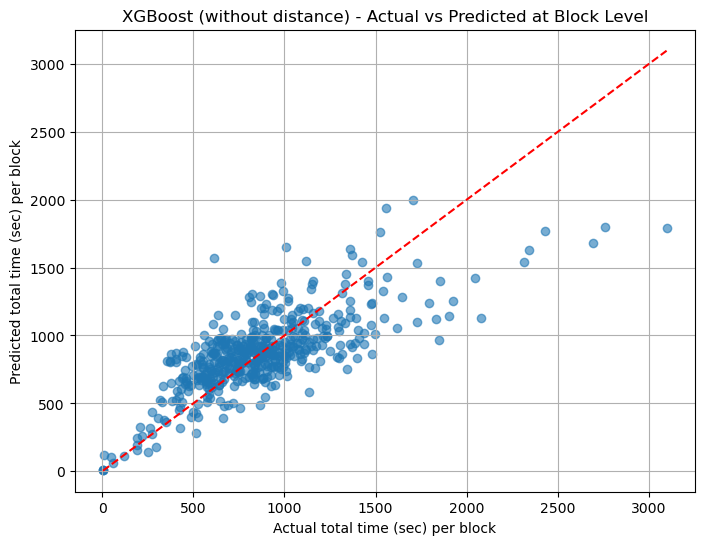

In [ ]:
# Plot actual vs predicted for the best model (XGBoost without distance) at block level
best_model = "XGBoost (without distance)"
plot_df = block_detail_df[block_detail_df["Warehouse"] == WAREHOUSE].copy()
# limit to WC20 and 30
# plot_df = plot_df[plot_df["WorkCode"].isin(["20", "30"])].copy()
plot_df = plot_df[plot_df["pred_xgb_no_dist"].notna()].copy()
plt.figure(figsize=(8, 6))
plt.scatter(plot_df["actual_time"], plot_df["pred_xgb_no_dist"], alpha=0.6)
plt.plot([plot_df["actual_time"].min(), plot_df["actual_time"].max()], [plot_df["actual_time"].min(), plot_df["actual_time"].max()], color="red", linestyle="--")
plt.xlabel("Actual total time (sec) per block")
plt.ylabel("Predicted total time (sec) per block")
plt.title(f"{best_model} - Actual vs Predicted at Block Level")
plt.grid(True)
plt.show()

In [ ]:
display(block_detail_df.head(5))

,BlockID,actual_time,pred_naive,pred_naive_median,pred_lr,pred_lr_n,pred_rf_with_dist,pred_rf_no_dist,pred_xgb_with_dist,pred_xgb_no_dist,WorkCode,UserID,date,n_tasks,Warehouse
0,217_2025-12-02_0,1558.016,1671.994497,1357.02,1634.522812,1609.688368,2124.761717,2107.692041,1939.343628,1937.346191,10,217,2025-12-02,20,OE
1,217_2025-12-02_1,1703.270,1671.994497,1357.02,1454.385639,1331.301003,2110.609774,2120.012515,2061.311523,1995.236084,10,217,2025-12-02,20,OE
2,217_2025-12-02_2,615.330,1671.994497,1357.02,1018.444872,1148.948459,1371.479554,1733.709540,1209.177856,1572.394775,10,217,2025-12-02,20,OE
3,217_2025-12-02_3,1148.107,1671.994497,1357.02,1536.442488,1243.450437,1832.452903,1665.820924,1530.442505,1344.908813,10,217,2025-12-02,20,OE
4,323_2025-12-02_0,2760.521,1671.994497,1357.02,1457.961758,1356.509068,1834.517921,1891.030931,1709.353760,1797.705566,10,323,2025-12-02,20,OE


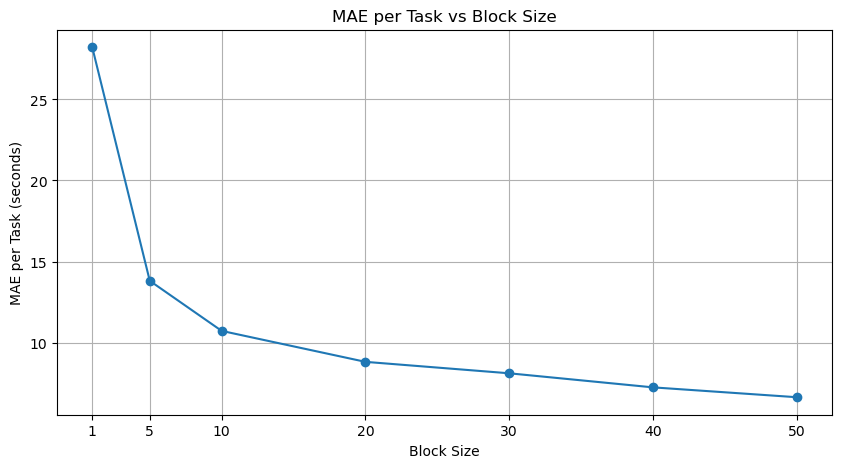

In [ ]:
# Plot the MAE_per_task vs BlockSize as a line chart
chunk_sizes = [1, 5, 10, 20, 30, 40, 50]
MAE_per_task = [28.22, 13.809, 10.72, 8.81, 8.104, 7.236, 6.628]
import matplotlib.pyplot as plt 
plt.figure(figsize=(10,5))
plt.plot(chunk_sizes, MAE_per_task, marker='o')
plt.xlabel("Block Size")
plt.ylabel("MAE per Task (seconds)")
plt.title("MAE per Task vs Block Size")
plt.xticks(chunk_sizes)
plt.grid()
plt.show()